## Titanic Survival Prediction 

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [10]:
Data={"passengerId":[1,2,3,4,5],
      "survied":[0,1,1,1,0],
      "Pclass":[3,1,3,1,3],
      "Sex":["Male","Femal","Male","Femal","Male"],
      "Age":[22,33,44,55,22],
      "Sibsp":[1,1,0,1,0]
      }
df=pd.DataFrame(Data)
df

,passengerId,survied,Pclass,Sex,Age,Sibsp
0,1,0,3,Male,22,1
1,2,1,1,Femal,33,1
2,3,1,3,Male,44,0
3,4,1,1,Femal,55,1
4,5,0,3,Male,22,0


## Uderstanding the dataset

In [11]:
df.head()

,passengerId,survied,Pclass,Sex,Age,Sibsp
0,1,0,3,Male,22,1
1,2,1,1,Femal,33,1
2,3,1,3,Male,44,0
3,4,1,1,Femal,55,1
4,5,0,3,Male,22,0


In [19]:
df.tail()

,passengerId,survied,Pclass,Sex,Age,Sibsp
0,1,0,3,Male,22,1
1,2,1,1,Femal,33,1
2,3,1,3,Male,44,0
3,4,1,1,Femal,55,1
4,5,0,3,Male,22,0


In [13]:
df.describe

<bound method NDFrame.describe of    passengerId  survied  Pclass    Sex  Age  Sibsp
0            1        0       3   Male   22      1
1            2        1       1  Femal   33      1
2            3        1       3   Male   44      0
3            4        1       1  Femal   55      1
4            5        0       3   Male   22      0>

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   passengerId  5 non-null      int64 
 1   survied      5 non-null      int64 
 2   Pclass       5 non-null      int64 
 3   Sex          5 non-null      object
 4   Age          5 non-null      int64 
 5   Sibsp        5 non-null      int64 
dtypes: int64(5), object(1)
memory usage: 372.0+ bytes


In [15]:
df.columns

Index(['passengerId', 'survied', 'Pclass', 'Sex', 'Age', 'Sibsp'], dtype='object')

In [16]:
df.shape

(5, 6)

## Checking the Missing values 

In [18]:
df.isnull().sum()

passengerId    0
survied        0
Pclass         0
Sex            0
Age            0
Sibsp          0
dtype: int64

## Handle Missing values

In [24]:
df["Age"]=df["Age"].fillna(df["Age"].median())

## checking the Duplicates 

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.drop_duplicates(inplace=True)

In [32]:
df.columns

Index(['passengerId', 'survied', 'Pclass', 'Sex', 'Age', 'Sibsp'], dtype='object')

## exploratory data Analysis

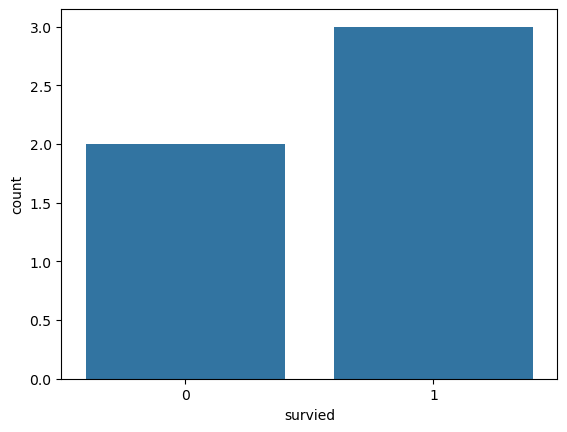

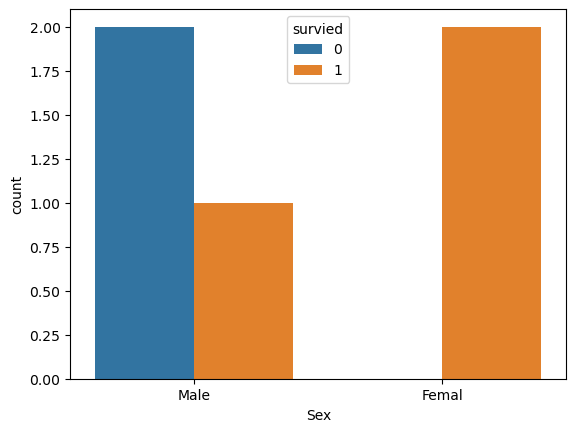

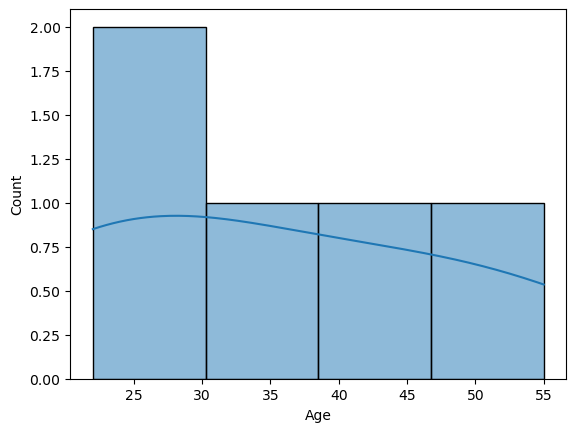

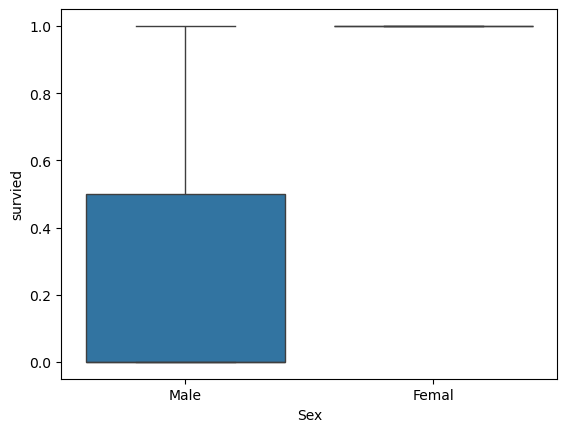

In [42]:
sns.countplot(x="survied",data=df)
plt.show()
sns.countplot(x="Sex",hue="survied",data=df)
plt.show()
sns.histplot(df["Age"],kde=True)
plt.show()
sns.boxplot(x="Sex",y="survied",data=df)
plt.show()

## select Features

In [51]:
x=df[['passengerId', 'survied', 'Pclass', 'Sex', 'Age', 'Sibsp']]
y=df["survied"]
le_sex=LabelEncoder()
x["Sex"]=le_sex.fit_transform(x["Sex"]) # converting catogerical data in to numerical data 

In [52]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## Creating the machine Learning model 

Accuracy: 0.0
[[0 0]
 [1 0]]


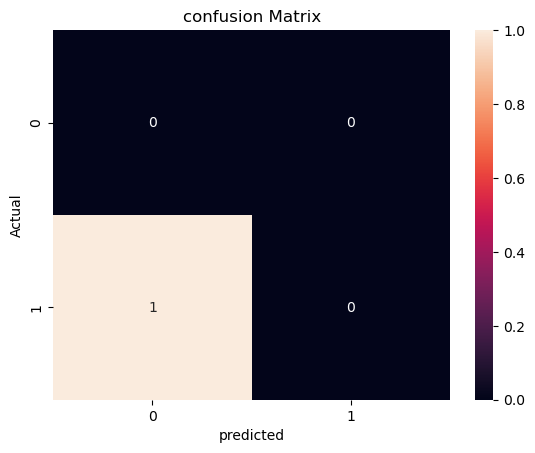

In [65]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train) # traing the model 
predictions=model.predict(x_test) # making predictions 
accuracy=accuracy_score(y_test,predictions) # checking the accuracy
print("Accuracy:",accuracy)
cm=confusion_matrix(y_test,predictions)
print(cm)
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("confusion Matrix")
plt.show()

Classification report 

In [66]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0

